# ECEF(地球中心地理座標系)からGPS座標系に変換する

# すじぐも

In [25]:
import re
import matplotlib
matplotlib.rc('font', family='Noto Sans CJK JP')

#CloudCompareのPoint picking機能を使って、点群から測量地点を選択肢し、PropertiesのLabel項目のBodyの内容を下に貼り付ける
data = """
P#9555601: (-4148720.000000;4094060.000000;2583840.000000)
Color: (127;137;152)
P#11131592: (-4148260.000000;4093880.000000;2584640.000000)
Color: (114;121;135)
P#15207002: (-4147820.000000;4094530.000000;2585080.000000)
Color: (143;141;149)
P#3522412: (-4147530.000000;4093850.000000;2586000.000000)
Color: (115;121;138)
P#17183631: (-4146850.000000;4094250.000000;2587110.000000)
Color: (169;162;167)
P#19537601: (-4146080.000000;4093950.000000;2588250.000000)
Color: (144;141;148)
P#19655579: (-4145870.000000;4093820.000000;2589570.000000)
Color: (189;180;184)
P#19352291: (-4145640.000000;4093430.000000;2590840.000000)
Color: (97;106;121)
P#4549866: (-4145280.000000;4093640.000000;2591920.000000)
Color: (162;158;166)
P#19557584: (-4145000.000000;4093580.000000;2592850.000000)
Color: (165;161;167)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])


X: -4148720.0, Y: 4094060.0, Z: 2583840.0
X: -4148260.0, Y: 4093880.0, Z: 2584640.0
X: -4147820.0, Y: 4094530.0, Z: 2585080.0
X: -4147530.0, Y: 4093850.0, Z: 2586000.0
X: -4146850.0, Y: 4094250.0, Z: 2587110.0
X: -4146080.0, Y: 4093950.0, Z: 2588250.0
X: -4145870.0, Y: 4093820.0, Z: 2589570.0
X: -4145640.0, Y: 4093430.0, Z: 2590840.0
X: -4145280.0, Y: 4093640.0, Z: 2591920.0
X: -4145000.0, Y: 4093580.0, Z: 2592850.0


index1番目が壁ぐもに近い

In [102]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in label:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
coordinate = np.array(coordinate)
print(len(coordinate))
print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (24.050572499322755, 135.37993752157584, 1080.8845965001199)
x_geod_from_ecef= (24.05883700277812, 135.37802066946608, 992.5371878232945)
x_geod_from_ecef= (24.061935823106854, 135.37043434791096, 1302.9160959251437)
x_geod_from_ecef= (24.07203693368344, 135.37318919287802, 1053.4749720041339)
x_geod_from_ecef= (24.08193228730289, 135.36569354557406, 1321.0583703910543)
x_geod_from_ecef= (24.09412200790983, 135.3624730903812, 1093.7048785864124)
x_geod_from_ecef= (24.105886192201964, 135.36193177855793, 1412.9189138725017)
x_geod_from_ecef= (24.11796352059205, 135.36307163408443, 1532.2463219176389)
x_geod_from_ecef= (24.127261063907063, 135.35911446034504, 1874.5123070399623)
x_geod_from_ecef= (24.135812163876608, 135.35759933484243, 2034.4370472347198)
10
1369.8690691294983


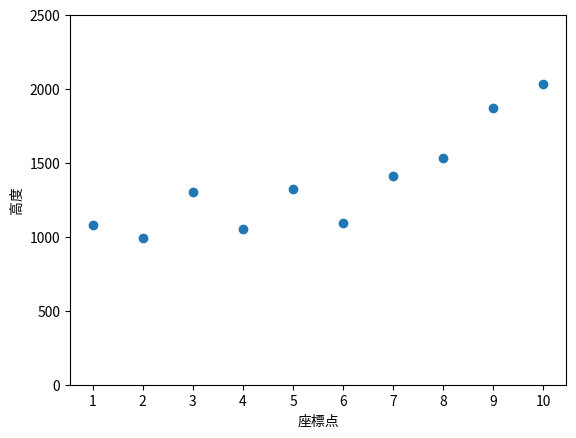

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = coordinate[:,2]

plt.scatter(range(1,len(data)+1), data)
# x軸のメモリを指定
plt.xticks(range(1,len(data)+1))
plt.xlabel("座標点")
plt.ylabel("高度")
# y軸の目盛りの指定
plt.yticks(range(0, 3000, 500))
plt.show()


# 筋雲２

In [105]:
import re

data = """
P#12961857: (-4141080.000000;4103410.000000;2582250.000000)
Color: (186;179;177)
P#10700346: (-4141480.000000;4102830.000000;2583280.000000)
Color: (172;167;170)
P#5770745: (-4141350.000000;4102630.000000;2584080.000000)
Color: (169;163;167)
P#2404221: (-4140960.000000;4102220.000000;2586060.000000)
Color: (190;181;181)
P#4513217: (-4140810.000000;4101780.000000;2587150.000000)
Color: (173;165;169)
P#8490448: (-4140550.000000;4101530.000000;2587620.000000)
Color: (169;163;165)
P#5354305: (-4140550.000000;4101260.000000;2588180.000000)
Color: (159;154;162)
P#11128807: (-4140530.000000;4100960.000000;2588960.000000)
Color: (173;167;168)
P#12283462: (-4140400.000000;4100670.000000;2589600.000000)
Color: (190;183;181)
P#1498775: (-4140300.000000;4100300.000000;2590680.000000)
Color: (187;179;178)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])


X: -4141080.0, Y: 4103410.0, Z: 2582250.0
X: -4141480.0, Y: 4102830.0, Z: 2583280.0
X: -4141350.0, Y: 4102630.0, Z: 2584080.0
X: -4140960.0, Y: 4102220.0, Z: 2586060.0
X: -4140810.0, Y: 4101780.0, Z: 2587150.0
X: -4140550.0, Y: 4101530.0, Z: 2587620.0
X: -4140550.0, Y: 4101260.0, Z: 2588180.0
X: -4140530.0, Y: 4100960.0, Z: 2588960.0
X: -4140400.0, Y: 4100670.0, Z: 2589600.0
X: -4140300.0, Y: 4100300.0, Z: 2590680.0


In [106]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in label:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
coordinate = np.array(coordinate)
print(len(coordinate))
print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (24.033265748309613, 135.26178902452025, 1475.9082492587809)
x_geod_from_ecef= (24.042212759746747, 135.2686053356822, 1782.1559614945622)
x_geod_from_ecef= (24.049664273778742, 135.26910257787776, 1895.2502743124824)
x_geod_from_ecef= (24.06806387330842, 135.2692677045874, 2185.9704127244004)
x_geod_from_ecef= (24.078578279957675, 135.27130277752923, 2250.567401139361)
x_geod_from_ecef= (24.083779237035184, 135.27125005023197, 2113.076213291861)
x_geod_from_ecef= (24.089093350618263, 135.2731358917815, 2168.1545504298874)
x_geod_from_ecef= (24.096350060923193, 135.27509304433698, 2280.86639684116)
x_geod_from_ecef= (24.102715241431262, 135.276219433243, 2271.5942241572925)
x_geod_from_ecef= (24.112834028502732, 135.27811241671037, 2410.2183815858907)
10
2083.376206523568


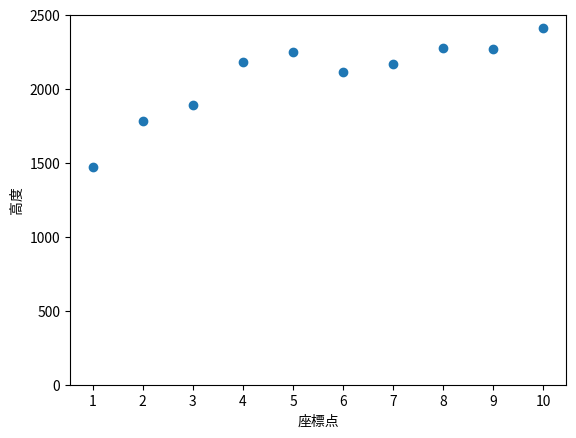

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = coordinate[:,2]

plt.scatter(range(1,len(data)+1), data)
# x軸のメモリを指定
plt.xticks(range(1,len(data)+1))
plt.xlabel("座標点")
plt.ylabel("高度")
# y軸の目盛りの指定

plt.yticks(range(0, 3000, 500))
plt.show()


# 雲頂

In [108]:
import re

data = """
P#16456804: (-4146320.000000;4126430.000000;2572760.000000)
Color: (104;123;142)
P#15656833: (-4145960.000000;4126790.000000;2573130.000000)
Color: (104;121;140)
P#15585768: (-4145560.000000;4127050.000000;2573800.000000)
Color: (117;130;143)
P#15086642: (-4145380.000000;4127220.000000;2574110.000000)
Color: (117;129;142)
P#15822865: (-4145070.000000;4127430.000000;2574690.000000)
Color: (111;124;138)
P#5224392: (-4144450.000000;4127520.000000;2574930.000000)
Color: (108;121;135)
P#13127348: (-4144300.000000;4127840.000000;2575480.000000)
Color: (105;120;136)
P#15749316: (-4143410.000000;4127950.000000;2575810.000000)
Color: (115;128;142)
P#11137721: (-4143190.000000;4128160.000000;2576300.000000)
Color: (123;134;147)
P#4516818: (-4142920.000000;4127960.000000;2576930.000000)
Color: (121;131;145)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])

X: -4146320.0, Y: 4126430.0, Z: 2572760.0
X: -4145960.0, Y: 4126790.0, Z: 2573130.0
X: -4145560.0, Y: 4127050.0, Z: 2573800.0
X: -4145380.0, Y: 4127220.0, Z: 2574110.0
X: -4145070.0, Y: 4127430.0, Z: 2574690.0
X: -4144450.0, Y: 4127520.0, Z: 2574930.0
X: -4144300.0, Y: 4127840.0, Z: 2575480.0
X: -4143410.0, Y: 4127950.0, Z: 2575810.0
X: -4143190.0, Y: 4128160.0, Z: 2576300.0
X: -4142920.0, Y: 4127960.0, Z: 2576930.0


In [109]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in label:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
coordinate = np.array(coordinate)
#print('              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31')
print(len(coordinate))
print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (23.882071013987407, 135.1377547802915, 15843.46748090567)
x_geod_from_ecef= (23.88512235316054, 135.13276820009582, 15992.174034897642)
x_geod_from_ecef= (23.89100438690273, 135.12819933599508, 16172.004851544187)
x_geod_from_ecef= (23.89358473447856, 135.12577541336728, 16290.593991333386)
x_geod_from_ecef= (23.898621083674723, 135.12217540268833, 16460.16331716875)
x_geod_from_ecef= (23.90196829199476, 135.1172654389144, 16213.80903488682)
x_geod_from_ecef= (23.906060293133024, 135.11400765534864, 16545.95607166422)
x_geod_from_ecef= (23.910795095078004, 135.10709142387202, 16174.233087075856)
x_geod_from_ecef= (23.914856961096017, 135.10411294628616, 16365.876341263745)
x_geod_from_ecef= (23.92125701375818, 135.10363394545362, 16317.414638454438)
10
16237.569284919471


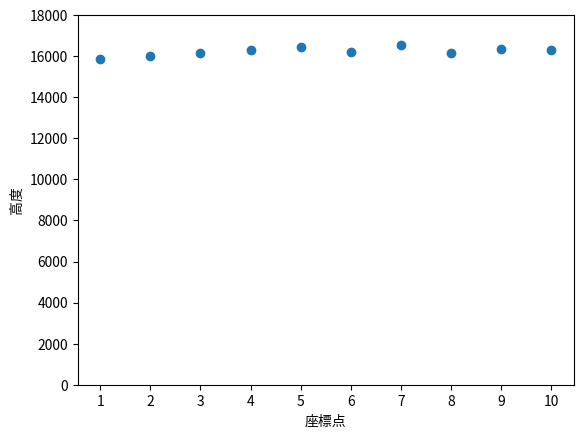

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = coordinate[:,2]

plt.scatter(range(1,len(data)+1), data)
# x軸のメモリを指定
plt.xticks(range(1,len(data)+1))
plt.xlabel("座標点")
plt.ylabel("高度")
# y軸の目盛りの指定
plt.yticks(range(0, 20000, 2000))
plt.show()


# 雲の傘

In [111]:
import re

data = """
P#8705888: (-4150600.000000;4107370.000000;2573320.000000)
Color: (155;153;161)
P#13387094: (-4149880.000000;4108030.000000;2574010.000000)
Color: (185;178;180)
P#13495591: (-4149650.000000;4108500.000000;2573530.000000)
Color: (182;176;178)
P#12300238: (-4148760.000000;4109250.000000;2573560.000000)
Color: (171;167;172)
P#10763315: (-4148030.000000;4109090.000000;2574980.000000)
Color: (144;143;154)
P#18892190: (-4150120.000000;4107780.000000;2573880.000000)
Color: (182;176;179)
P#17434060: (-4151380.000000;4107220.000000;2572010.000000)
Color: (179;174;178)
P#12605496: (-4150980.000000;4107270.000000;2572840.000000)
Color: (169;164;169)
P#18239371: (-4150950.000000;4107990.000000;2570020.000000)
Color: (179;174;177)
P#17031189: (-4151160.000000;4108110.000000;2568180.000000)
Color: (145;144;154)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])

X: -4150600.0, Y: 4107370.0, Z: 2573320.0
X: -4149880.0, Y: 4108030.0, Z: 2574010.0
X: -4149650.0, Y: 4108500.0, Z: 2573530.0
X: -4148760.0, Y: 4109250.0, Z: 2573560.0
X: -4148030.0, Y: 4109090.0, Z: 2574980.0
X: -4150120.0, Y: 4107780.0, Z: 2573880.0
X: -4151380.0, Y: 4107220.0, Z: 2572010.0
X: -4150980.0, Y: 4107270.0, Z: 2572840.0
X: -4150950.0, Y: 4107990.0, Z: 2570020.0
X: -4151160.0, Y: 4108110.0, Z: 2568180.0


In [112]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in label:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
coordinate = np.array(coordinate)
#print('              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31')
print(len(coordinate))
print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (23.92462174702121, 135.29993738443974, 6573.411551062688)
x_geod_from_ecef= (23.930483777734427, 135.29036497671922, 6809.8881363634055)
x_geod_from_ecef= (23.925914988796013, 135.28549999858274, 6768.048799097814)
x_geod_from_ecef= (23.92654513158462, 135.27412645124485, 6684.551845748953)
x_geod_from_ecef= (23.940560870709586, 135.2702008829462, 6683.6561328230755)
x_geod_from_ecef= (23.929431483330156, 135.29376500651452, 6752.30879171785)
x_geod_from_ecef= (23.912179124476364, 135.3063663949523, 6452.687741576581)
x_geod_from_ecef= (23.919933681229594, 135.3032573652135, 6561.385443584488)
x_geod_from_ecef= (23.894906503187155, 135.29802910405218, 5862.044409694404)
x_geod_from_ecef= (23.878876269515168, 135.2986415228889, 5330.627299452034)
10
6447.861015112129


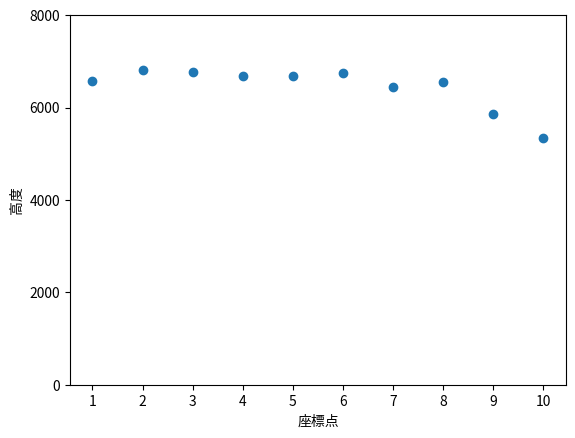

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = coordinate[:,2]

plt.scatter(range(1,len(data)+1), data)
# x軸のメモリを指定
plt.xticks(range(1,len(data)+1))
plt.xlabel("座標点")
plt.ylabel("高度")
# y軸の目盛りの指定
plt.yticks(range(0, 10000, 2000))
plt.show()


# GPSと比較

In [114]:
import re

data = """
P#24551763: (-4133410.000000;4124580.000000;2594260.000000)
P#24552812: (-4143390.000000;4107820.000000;2604350.000000)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])

X: -4133410.0, Y: 4124580.0, Z: 2594260.0
X: -4143390.0, Y: 4107820.0, Z: 2604350.0


In [115]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in label:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
coordinate = np.array(coordinate)
print('              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31')
print(len(coordinate))
#print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (24.09725798904775, 135.06126448933557, 15037.019228963178)
x_geod_from_ecef= (24.19766692903033, 135.24699386548386, 14836.4530782613)
              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31
2


In [ ]:
# 開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31

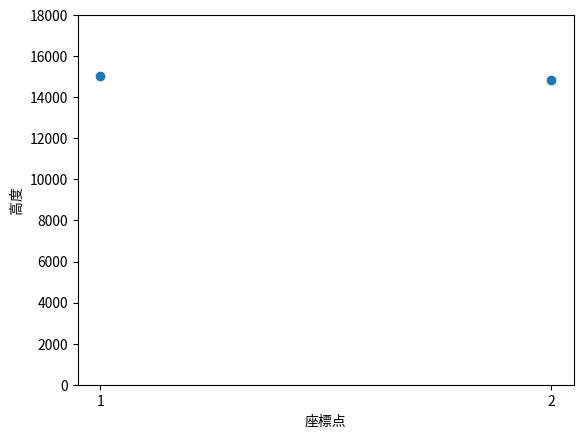

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = coordinate[:,2]

plt.scatter(range(1,len(data)+1), data)
# x軸のメモリを指定
plt.xticks(range(1,len(data)+1))
plt.xlabel("座標点")
plt.ylabel("高度")
# y軸の目盛りの指定
plt.yticks(range(0, 20000, 2000))
plt.show()


# colmap
雲頂[18:26:51] [Picked]	- P#10578483: (-4144188.250000;4130796.750000;2568668.000000)

In [1]:
import re

data = """
P#10578483: (-4144188.250000;4130796.750000;2568668.000000)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])

X: -4144188.25, Y: 4130796.75, Z: 2568668.0


In [3]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in label:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
coordinate = np.array(coordinate)
#print('              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31')
print(len(coordinate))
#print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (23.84264228451658, 135.09272231448585, 15624.923791276353)
1


# 断層の壁雲高度

In [2]:
import re
#　下段、上段
data = """
P#17843106: (-4145720.000000;4103860.000000;2575140.000000)
Color: (203;196;191)
P#5989857: (-4144580.000000;4104890.000000;2574980.000000)
Color: (195;190;185)
P#18379641: (-4142970.000000;4105860.000000;2575270.000000)
Color: (179;174;172)
P#17266609: (-4141860.000000;4106510.000000;2576540.000000)
Color: (201;195;190)
P#15387757: (-4140520.000000;4107830.000000;2576810.000000)
Color: (171;168;169)
P#5842633: (-4139750.000000;4109200.000000;2578260.000000)
Color: (100;117;134)
P#11055710: (-4138200.000000;4109290.000000;2578730.000000)
Color: (122;133;146)
P#3904026: (-4136780.000000;4110040.000000;2580680.000000)
Color: (190;185;185)
P#18379642: (-4135710.000000;4110490.000000;2581160.000000)
Color: (197;191;189)
P#584831: (-4134900.000000;4111040.000000;2581070.000000)
Color: (194;189;188)

P#4573583: (-4149500.000000;4108780.000000;2573900.000000)
Color: (185;179;179)
P#10763315: (-4148030.000000;4109090.000000;2574980.000000)
Color: (144;143;154)
P#19367742: (-4147550.000000;4109770.000000;2574040.000000)
Color: (152;151;159)
P#15047763: (-4146630.000000;4111480.000000;2574050.000000)
Color: (172;167;173)
P#13347645: (-4144860.000000;4113630.000000;2574230.000000)
Color: (167;163;169)
P#12281231: (-4143880.000000;4114620.000000;2574910.000000)
Color: (165;161;167)
P#16126143: (-4142110.000000;4115920.000000;2576300.000000)
Color: (152;150;159)
P#15436891: (-4141120.000000;4115580.000000;2577890.000000)
Color: (165;161;168)
P#489425: (-4139560.000000;4116730.000000;2578830.000000)
Color: (181;176;177)
P#12202117: (-4139000.000000;4116180.000000;2580320.000000)
Color: (147;146;155)
"""

# 正規表現パターン
pattern = r"\((-?\d+\.\d+);(-?\d+\.\d+);(-?\d+\.\d+)\)"

# パターンに一致する座標を抽出
matches = re.findall(pattern, data)

label = []
# 結果を表示
for match in matches:
    x, y, z = map(float, match)
    print(f"X: {x}, Y: {y}, Z: {z}")
    label.append([x,y,z])

X: -4145720.0, Y: 4103860.0, Z: 2575140.0
X: -4144580.0, Y: 4104890.0, Z: 2574980.0
X: -4142970.0, Y: 4105860.0, Z: 2575270.0
X: -4141860.0, Y: 4106510.0, Z: 2576540.0
X: -4140520.0, Y: 4107830.0, Z: 2576810.0
X: -4139750.0, Y: 4109200.0, Z: 2578260.0
X: -4138200.0, Y: 4109290.0, Z: 2578730.0
X: -4136780.0, Y: 4110040.0, Z: 2580680.0
X: -4135710.0, Y: 4110490.0, Z: 2581160.0
X: -4134900.0, Y: 4111040.0, Z: 2581070.0
X: -4149500.0, Y: 4108780.0, Z: 2573900.0
X: -4148030.0, Y: 4109090.0, Z: 2574980.0
X: -4147550.0, Y: 4109770.0, Z: 2574040.0
X: -4146630.0, Y: 4111480.0, Z: 2574050.0
X: -4144860.0, Y: 4113630.0, Z: 2574230.0
X: -4143880.0, Y: 4114620.0, Z: 2574910.0
X: -4142110.0, Y: 4115920.0, Z: 2576300.0
X: -4141120.0, Y: 4115580.0, Z: 2577890.0
X: -4139560.0, Y: 4116730.0, Z: 2578830.0
X: -4139000.0, Y: 4116180.0, Z: 2580320.0


In [4]:
dowon_point = label[:10]
up_point = label[10:]

In [5]:
print(len(dowon_point))
print(len(up_point))

10
10


In [8]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in up_point:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
up_point_coordinate = np.array(coordinate)
#print('              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31')
print(len(up_point_coordinate))
#print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (23.928634499738706, 135.28251224638225, 7000.757573340003)
x_geod_from_ecef= (23.940560870709586, 135.2702008829462, 6683.6561328230755)
x_geod_from_ecef= (23.932308201812923, 135.26214552004785, 6428.051011326982)
x_geod_from_ecef= (23.930376965844705, 135.24387353616117, 6935.187849588604)
x_geod_from_ecef= (23.930918565719622, 135.21666656554828, 7243.619311713484)
x_geod_from_ecef= (23.93651648481843, 135.2029990305379, 7521.281536778592)
x_geod_from_ecef= (23.94921563828869, 135.18171058163637, 7774.977356691149)
x_geod_from_ecef= (23.965767667911194, 135.17722934606425, 7559.87012565579)
x_geod_from_ecef= (23.974596109726466, 135.1584318516458, 7671.71699495877)
x_geod_from_ecef= (23.98974972465151, 135.15838374912636, 7560.185277956905)
10


In [35]:
np.mean(up_point_coordinate[:,2])

7237.9303170833355

In [9]:
from math import isclose
from pytest import approx
from pymap3d.ecef import ecef2geodetic
import numpy as np

def test_ecef2geodetic(x_ecef):
    #x_ecef = [-4151335.500000,4098100.000000,2587258.750000]
    #x_geod = [36.106112803, 140.08720184, 70.336]
    x_geod_from_ecef = ecef2geodetic(x_ecef[0], x_ecef[1], x_ecef[2])
    print( "x_geod_from_ecef=", x_geod_from_ecef)
    # print( "x_geod=", x_geod)
    # assert x_geod[0] == approx( x_geod_from_ecef[0] )
    # assert x_geod[1] == approx( x_geod_from_ecef[1] )
    # assert isclose(x_geod[2], x_geod_from_ecef[2], rel_tol=0.01)
    return x_geod_from_ecef

coordinate = []
for i in dowon_point:
    coordinate.append(list(test_ecef2geodetic(x_ecef = i)))
dowon_point_coordinate = np.array(coordinate)
#print('              開始:24.131 134.998 14415.52, 終了:24.2395 135.2935 14413.31')
print(len(dowon_point_coordinate))
#print(np.mean(coordinate[:,2]))

x_geod_from_ecef= (23.961371376180864, 135.29072761843273, 1885.4043464142883)
x_geod_from_ecef= (23.96036456496703, 135.27566036879145, 1742.4179140906465)
x_geod_from_ecef= (23.96444677316689, 135.2577616502302, 1438.8976949781525)
x_geod_from_ecef= (23.97613461281845, 135.2455507458553, 1652.6430218522842)
x_geod_from_ecef= (23.97844173415726, 135.22707441196377, 1742.3542727948245)
x_geod_from_ecef= (23.988863644372067, 135.21219404426859, 2714.075521959656)
x_geod_from_ecef= (23.996543076999984, 135.20083858258934, 1958.198710920062)
x_geod_from_ecef= (24.014379352433057, 135.1857787334969, 2313.993922401322)
x_geod_from_ecef= (24.01995943349815, 135.17523162838538, 2105.8174373565025)
x_geod_from_ecef= (24.019903422023823, 135.16578746436053, 1898.6419774971223)
10


In [37]:
np.mean(dowon_point_coordinate[:,2])

1945.244482026486

In [30]:
distance_q = []
for i in range(len(up_point_coordinate)):
    q = np.linalg.norm(up_point_coordinate[i,2]-dowon_point_coordinate[i,2])
    distance_q.append(q)
    print(q)
print("mean: ", np.mean(distance_q))

5115.353226925714
4941.238218732429
4989.153316348829
5282.544827736319
5501.26503891866
4807.206014818937
5816.778645771087
5245.876203254467
5565.899557602267
5661.5433004597835
mean:  5292.685835056849


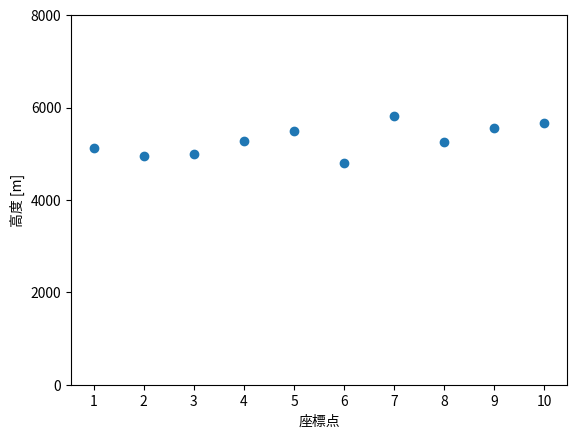

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = distance_q

plt.scatter(range(1,len(data)+1), data)
# x軸のメモリを指定
plt.xticks(range(1,len(data)+1))
plt.xlabel("座標点")
plt.ylabel("高度 [m]")
# y軸の目盛りの指定
plt.yticks(range(0, 10000, 2000))
plt.show()
